In [51]:
import numpy as np

In [52]:
import lightkurve as lk

# Search TESS observations
search = lk.search_lightcurve("TZ For", mission="TESS")

print(search)

# Download all sectors
lc_collection = search.download_all()

SearchResult containing 10 data products.

 #     mission     year       author      exptime target_name distance
                                             s                 arcsec 
--- -------------- ---- ----------------- ------- ----------- --------
  0 TESS Sector 04 2018              SPOC     120   176828796      0.0
  1 TESS Sector 04 2018         TESS-SPOC    1800   176828796      0.0
  2 TESS Sector 04 2018               QLP    1800   176828796      0.0
  3 TESS Sector 30 2020               QLP     600   176828796      0.0
  4 TESS Sector 31 2020               QLP     600   176828796      0.0
  5 TESS Sector 97 2025               QLP     200   176828796      0.0
  6 TESS Sector 04 2018             TASOC     120   176828796      0.0
  7 TESS Sector 04 2018 GSFC-ELEANOR-LITE    1800   176828796      0.0
  8 TESS Sector 04 2018             TASOC    1800   176828796      0.0
  9 TESS Sector 04 2018              TGLC    1800   176828796      0.0


In [53]:
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

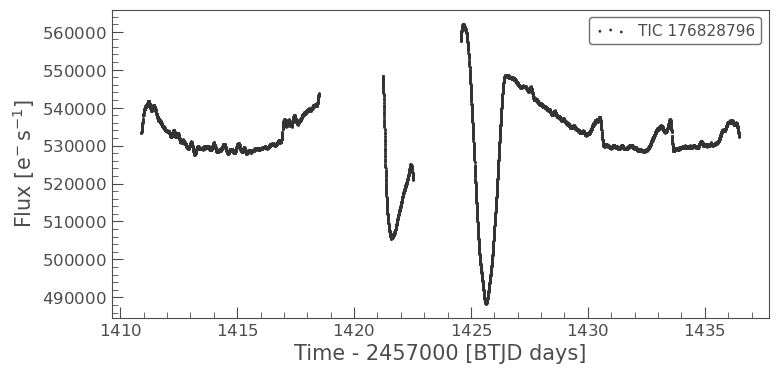

In [54]:
lc_collection[0].scatter()

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

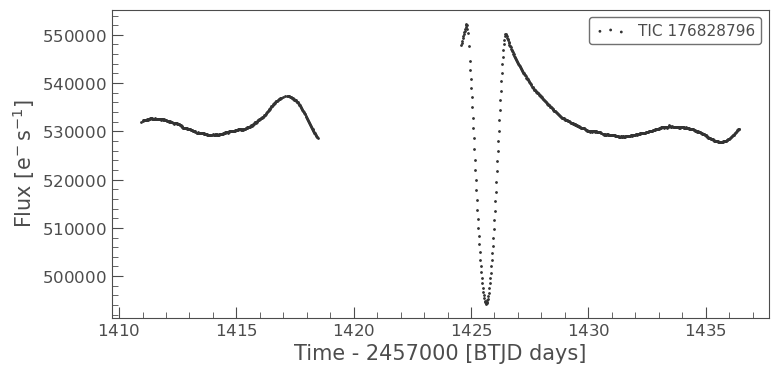

In [55]:
lc_collection[1].scatter()

(1424.0, 1428.0)

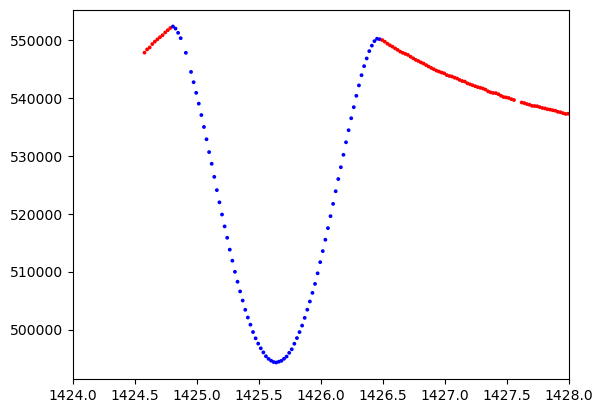

In [81]:
mask = (lc_collection[1].time.value > 1424.79) & (lc_collection[1].time.value < 1426.485)
colors = np.where(mask, 'blue', 'red')
plt.scatter(lc_collection[1].time.value, lc_collection[1].flux.value, s=3, c=colors)
plt.gca().set_xlim(1424, 1428)

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Normalized Flux'>

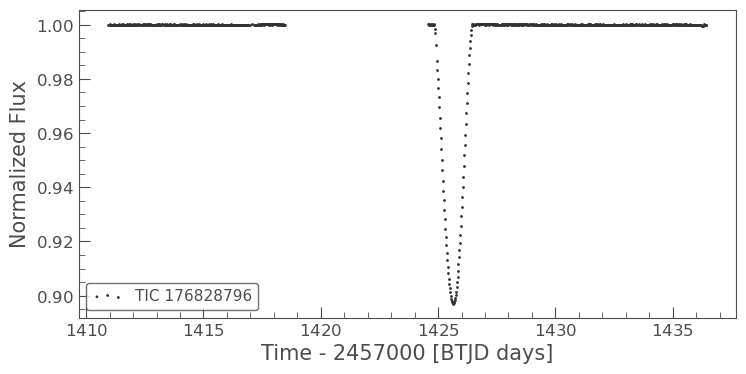

In [85]:
lc_collection[1].flatten(mask=mask, window_length=10).scatter()

In [91]:
import numpy as np

lc = lc_collection[1].flatten(mask=mask, window_length=10)
flux = np.asarray(lc.flux.filled(np.nan))
flux_err = np.asarray(lc.flux_err.filled(np.nan))

median_flux = np.nanmedian(flux)

mag = -2.5 * np.log10(flux / median_flux)

mag_err = (2.5 / np.log(10)) * (flux_err / flux)

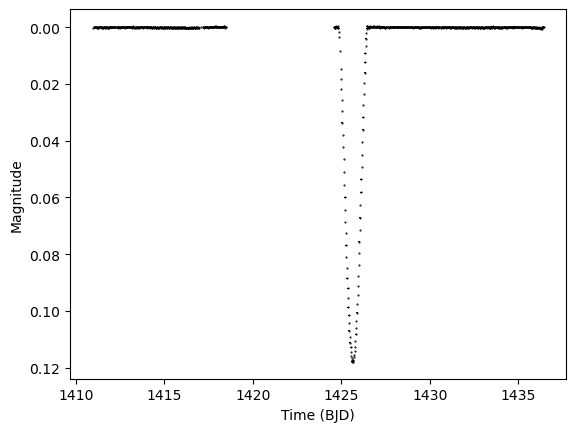

In [96]:
plt.errorbar(lc.time.value, mag, yerr=mag_err, fmt='.', markersize=1, color='black')
plt.gca().invert_yaxis()
plt.xlabel('Time (BJD)')
plt.ylabel('Magnitude')
plt.show()

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Normalized Flux'>

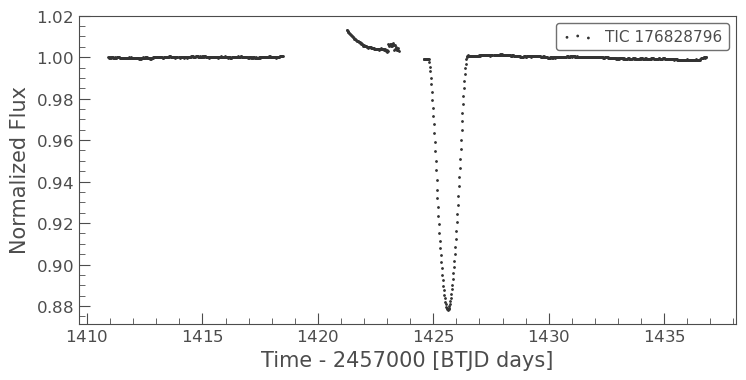

In [25]:
lc_collection[2].scatter()

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Normalized Flux'>

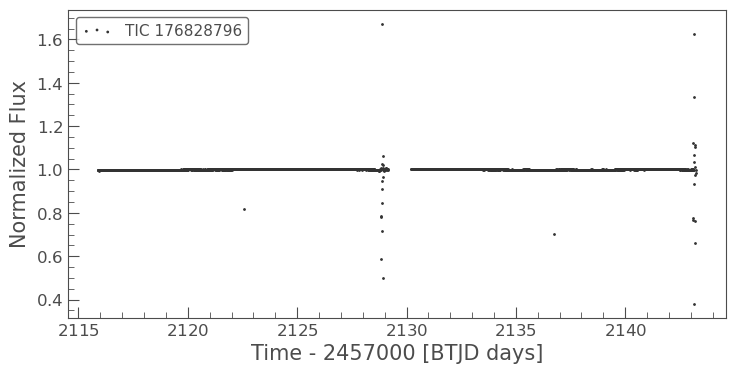

In [21]:
lc_collection[3].scatter()

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Normalized Flux'>

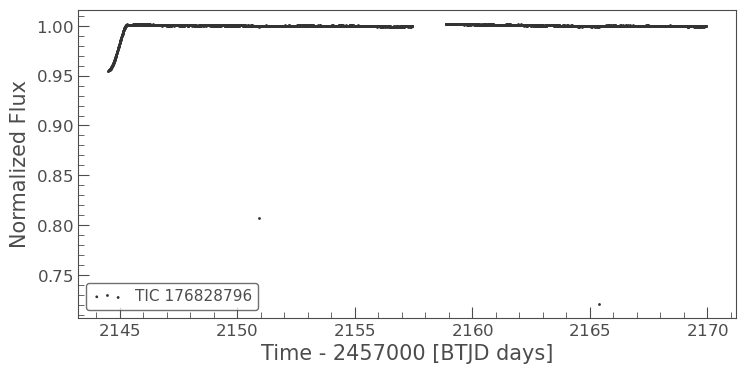

In [23]:
lc_collection[4].scatter()

In [26]:
import astropy.units as u

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Normalized Flux'>

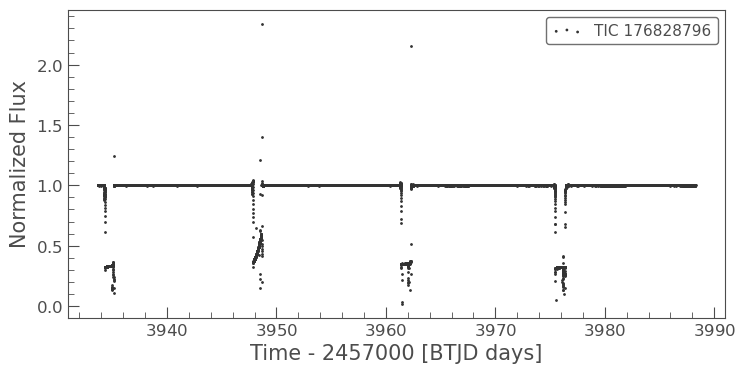

In [28]:
lc_collection[5].flatten().scatter()

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Normalized Flux'>

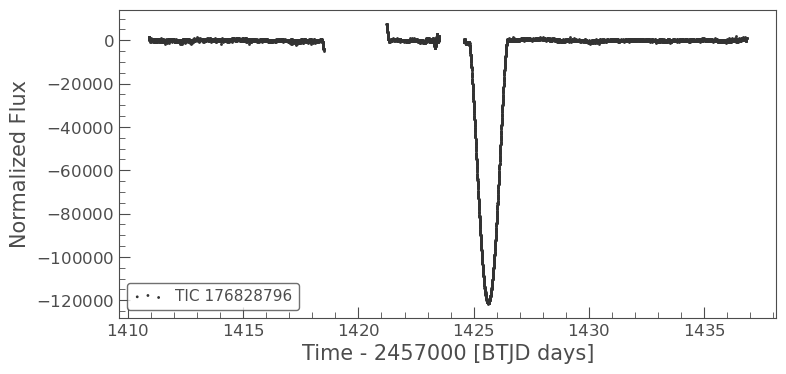

In [23]:
lc_collection[6].remove_outliers(sigma=10).scatter()

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Flux [$\\mathrm{e^{-}\\,s^{-1}}$]'>

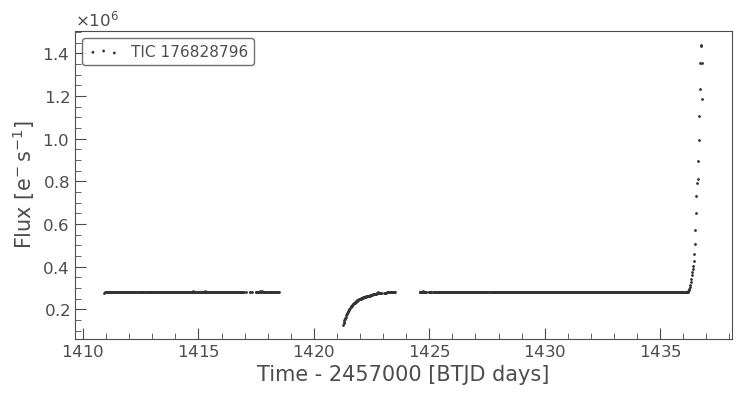

In [24]:
lc_collection[7].scatter()

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Normalized Flux'>

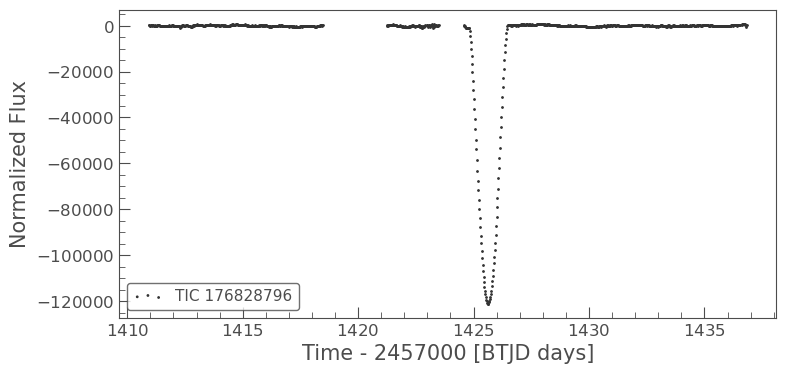

In [17]:
lc_collection[8].scatter()

<Axes: xlabel='Time - 2457000 [BTJD days]', ylabel='Normalized Flux'>

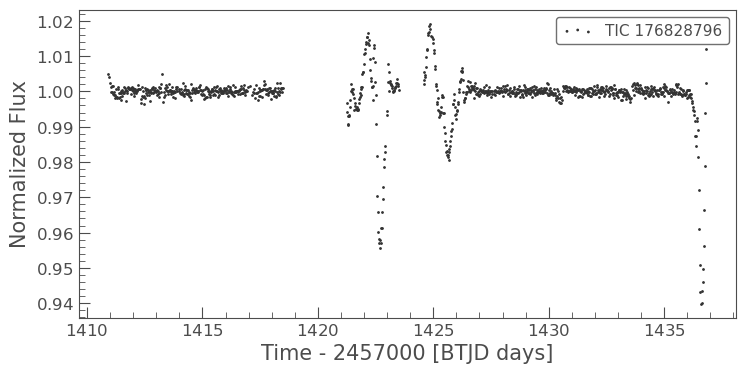

In [9]:
lc_collection[9].scatter()

In [76]:
import matplotlib.pyplot as plt
import matplotlib
%matplotlib inline
import numpy as np

In [77]:
lc8['flux'].value.filled(np.nan)

array([ 478.14495782,  206.32304987, -259.03785644, ...,  234.37619364,
       -563.46799395,  138.68580914], dtype='>f8')

<ErrorbarContainer object of 3 artists>

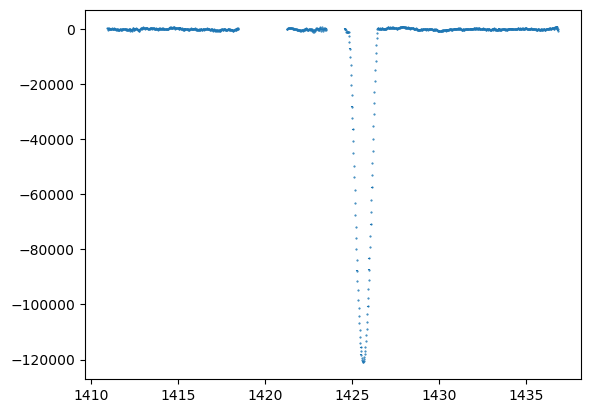

In [78]:
lc8 = lc_collection[8]
plt.errorbar(lc8['time'].value, lc8['flux'].value.filled(0.), yerr=lc8['flux_err'].value.filled(0.), fmt='.', markersize=1)